<a href="https://colab.research.google.com/github/Anagh19/Complex-Systems-Project/blob/Add-geojson-network/CS7065_DOI_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Setting up the import from Github for update ease, only need to run once per session

In [ ]:
from pathlib import Path

repo_path = Path("/content/Complex-Systems-Project")

if not repo_path.exists():
    !git clone https://github.com/Anagh19/Complex-Systems-Project

%cd /content/Complex-Systems-Project

PROJECT_ROOT = Path.cwd()

Cloning into 'Complex-Systems-Project'...
remote: Enumerating objects: 26, done.
remote: Counting objects: 100% (26/26), done.
remote: Compressing objects: 100% (26/26), done.
remote: Total 26 (delta 8), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (26/26), 1.97 MiB | 4.84 MiB/s, done.
Resolving deltas: 100% (8/8), done.
/content/Complex-Systems-Project


In [ ]:
try:
  import mesa
except:
  !pip install mesa --quiet
  import mesa

try:
  import mesa_geo as mg
except:
  !pip install -U --pre mesa-geo --quiet

try:
  import networkx as nx
except:
  !pip install networkx --quiet
  import networkx as nx

import numpy as np
import matplotlib.pyplot as plt
import math
import random
from shapely.geometry import Point
from mesa.discrete_space import CellCollection, Network

In [ ]:
geojson_regions = PROJECT_ROOT / "combined_counties.geojson"


Health Agent represents the individual health departments within a county.

In [14]:
class health_agent(mg.GeoAgent):
  # Each health agent represents one health department
  def __init__(
        self,
        model,
        geometry, # the shape of the health dept
        crs,
        adoption_chance,
        agent_type="Local, State",
        adoption_state="Technology Unknown",
        times_exposed = 0,

    ):
    super().__init__(model, geometry, crs)
    # Agent parameters
    self.atype = agent_type

  def __repr__(self):
    return f"{self.atype}" + " Health Department"

  def step(self):
    self.model.counts[self.atype] += 1 # Count agent type
    # Each step per agent

County Region Agent acts to hold the health departments to a geojson region and act as a part of a whole state. Functionally it only acts as a display parameter.

In [16]:
class County_Agent(mg.GeoAgent):
  # Neighbornhood Agent which is basically the county
  # Changes color based on if the agent within as adopted tech or not
  def __init__(
        self,
        model,
        geometry,
        crs,
        atype= "Not Adopted",
        adoption_threshold = 1
  ):
    super().__init__(model, geometry, crs)
    self.adoption_threshold = (
            adoption_threshold  # When an entire region has adopted technology
    )
    self.color_threshold()

  def step(self):
      self.model.counts[self.atpye] += 1 # Count agent type

  def color_threshold(self):
    # Changes color based on if the agent within as adopted tech or not
    agents_in_region = self.model.space.get_relation(health_agent,'within')
    # This gets number of health agents within the region agent
    adopted_agents = [ agents_in_region for agents_in_region in agents_in_region
                      if agents_in_region.type == "Technology Adopted"]
    if len(adopted_agents) >= self.adoption_threshold:
      self.atype = "Adopted"
    else:
      self.atype = "Not Adopted"

def __repr__(self):
        return "Neighborhood " + str(self.unique_id)

This cell holds the network which shall connect the agents and be the channels in which innovation flows

In [ ]:
from mesa.space import NetworkGrid
class health_model(mesa.Model):
  # Model class that will create healthcare network on geojson file hopefully
  unique_id = "HOODHUM"
  # Initialized with 300 health departments
  def __init__(self, pop_size=300):
    super().__init__()
    self.space = mg.GeoSpace(warn_crs_conversion=False)
    self.time = 0
    self.counts = None
    self.reset_counts()
    self.pop_size = pop_size
    self.grid = Network(graph,capacity = 1,random=self.random)

    # Sets up counties and States per geojson file
    ac = mg.AgentCreator(County_Agent, model=self)
    neighbourhood_agents = ac.from_file(self.geojson_regions)
    self.space.add_agents(neighbourhood_agents)

    # Generate PersonAgent population
    ac_population = mg.AgentCreator(
          PersonAgent,
          model=self,
          crs=self.space.crs,
    )

Anagh Code

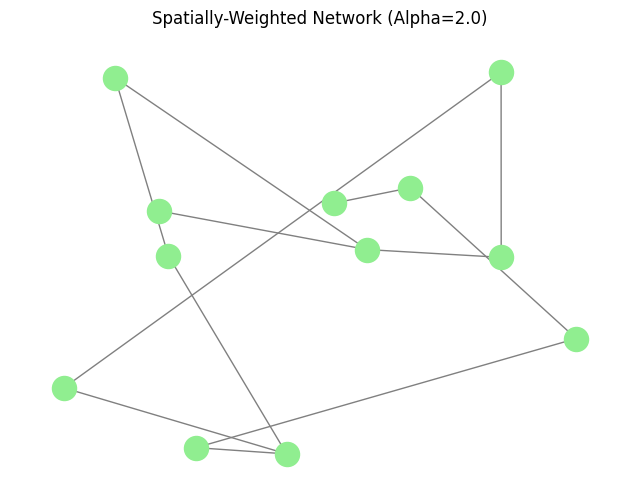

In [ ]:


def spatial_watts_strogatz(n, k, p, alpha=2.0):
    """
    Generates a geographically-weighted small-world graph.
    n: number of nodes
    k: initial local connections per node
    p: rewiring probability
    alpha: spatial decay parameter (higher = stricter geographical boundaries)
    """
    # 1. Start with a perfect, un-rewired ring lattice (p=0)
    G = nx.watts_strogatz_graph(n, k, 0)

    # 2. Assign random geographical coordinates (x, y) from 0 to 100
    for node in G.nodes():
        G.nodes[node]['pos'] = (random.uniform(0, 100), random.uniform(0, 100))

    nodes = list(G.nodes())

    # 3. The Rewiring Phase
    for u, v in list(G.edges()):
        if random.random() < p:
            # The edge is selected for rewiring; remove the old local connection
            G.remove_edge(u, v)

            candidates = []
            probabilities = []
            x1, y1 = G.nodes[u]['pos']

            # Going through all the nodes in the graph other than the ones we are connected to or our own node
            for target in nodes:
                if target == u or G.has_edge(u, target):
                    continue # Skip ourselves and nodes we are already connected to
                # Find distance between this node and our current node
                x2, y2 = G.nodes[target]['pos']
                # Euclidean distance
                distance = math.sqrt((x2 - x1)**2 + (y2 - y1)**2)

                # Inverse-distance weighting (adding 0.001 prevents division by zero)
                weight = 1.0 / (distance**alpha + 0.001)

                candidates.append(target)
                probabilities.append(weight)

            # Normalize the weights so they sum to 1.0 (creating a valid probability distribution)
            prob_sum = sum(probabilities)
            if prob_sum > 0:
                probabilities = [w / prob_sum for w in probabilities]

                # Choose the new target using our spatial probability distribution
                new_v = np.random.choice(candidates, p=probabilities)
                G.add_edge(u, new_v)

    return G

# --- Test and Visualize ---
n_nodes = 12
k_neighbors = 2
rewire_prob = 0.3
decay_factor = 2.0 # Try changing this to 0.0 to see the Orr et al. baseline!

# Generate our custom graph
custom_G = spatial_watts_strogatz(n_nodes, k_neighbors, rewire_prob, alpha=decay_factor)

# Extract positions for plotting
positions = nx.get_node_attributes(custom_G, 'pos')

# Plotting
plt.figure(figsize=(8, 6))
plt.title(f"Spatially-Weighted Network (Alpha={decay_factor})")
nx.draw(custom_G, positions, node_color='lightgreen', node_size=300, edge_color='gray')
plt.show()